In [32]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import joblib

In [2]:
df=pd.read_csv('C:\House price Prediction\Bengaluru_House_Data (1).csv')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\H'
<>:1: SyntaxWarning: invalid escape sequence '\H'
C:\Users\Shiv\AppData\Local\Temp\ipykernel_11736\1808831440.py:1: SyntaxWarning: invalid escape sequence '\H'
  df=pd.read_csv('C:\House price Prediction\Bengaluru_House_Data (1).csv')


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 1.6 MB


In [4]:
df=df.drop(['area_type','society','balcony'],axis=1)

In [5]:
df.isnull().sum()

availability     0
location         1
size            16
total_sqft       0
bath            73
price            0
dtype: int64

In [6]:
#handling missing values in location column
df['location'].value_counts() #count of houses in whitefield and sarajapur road is more than other locations
df['location']=df['location'].fillna("Sarjapur Road") 
df["location"].value_counts()

location
Whitefield                                         540
Sarjapur  Road                                     399
Electronic City                                    302
Kanakpura Road                                     273
Thanisandra                                        234
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1306, dtype: int64

In [7]:
df["size"].value_counts()
df['size']=df['size'].fillna("2 BHK")
df['size'].value_counts()

size
2 BHK         5215
3 BHK         4310
4 Bedroom      826
4 BHK          591
3 Bedroom      547
1 BHK          538
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
27 BHK           1
19 BHK           1
16 BHK           1
43 Bedroom       1
14 BHK           1
12 Bedroom       1
13 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [8]:
df.isnull().sum()

availability     0
location         0
size             0
total_sqft       0
bath            73
price            0
dtype: int64

In [9]:
mcd_bath=df['bath'].median()#[1,2,3,4,5,6,7,8,9,10 ]
mcd_bath
df['bath']=df['bath'].fillna(mcd_bath)

In [10]:
df["bath"]=df["bath"].astype(int)
df["bath"].unique()

array([ 2,  5,  3,  4,  6,  1,  9,  8,  7, 11, 10, 14, 27, 12, 16, 40, 15,
       13, 18])

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
loc = df['location'].value_counts()
loc_less_than_10 = loc[loc <= 10]
df['location'] = df['location'].apply(lambda x: 'other' if x in loc_less_than_10.index else x)
df['location'].value_counts()

location
other               2939
Whitefield           519
Sarjapur  Road       375
Electronic City      281
Kanakpura Road       238
                    ... 
Tindlu                11
NGR Layout            11
Doddakallasandra      11
Thyagaraja Nagar      11
HAL 2nd Stage         11
Name: count, Length: 233, dtype: int64

In [13]:
#handling size column
out=[int(i.split(' ')[0]) for i in df['size']] #2BHK
df['bhk']=out
df

,availability,location,size,total_sqft,bath,price,bhk
0,19-Dec,Electronic City Phase II,2 BHK,1056,2,39.07,2
1,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5,120.00,4
2,Ready To Move,Uttarahalli,3 BHK,1440,2,62.00,3
3,Ready To Move,Lingadheeranahalli,3 BHK,1521,3,95.00,3
4,Ready To Move,Kothanur,2 BHK,1200,2,51.00,2
...,...,...,...,...,...,...,...
13314,Ready To Move,Green Glen Layout,3 BHK,1715,3,112.00,3
13315,Ready To Move,Whitefield,5 Bedroom,3453,4,231.00,5
13316,Ready To Move,other,4 BHK,3600,5,400.00,4
13317,Ready To Move,Raja Rajeshwari Nagar,2 BHK,1141,2,60.00,2


In [14]:
#Handling total_sqft column
def clean_sqft(sqft):
    l=sqft.split('-')#[1200]
    if len(l)==2:
        return (float(l[0])+float(l[1]))/2
    try:#1200
        return float(l[0])
    except:#34,54j
        return None
    df["total_sqft"]=df["total_sqft"].apply(clean_sqft)
    df["total_sqft"]=df["total_sqft"].fillna(df["total_sqft"].mean())

In [15]:
def convert_sqft_to_num(x):
    tokens = str(x).split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)

In [16]:
#handling outliers in total_sqft column
# total_sqrt/bhk>=300--> #to keep only those rows where total_sqrt/bhk is greater than or equal to 300
df=df[(df['total_sqft']/df['bhk']<300)]
df.describe()


,total_sqft,bath,price,bhk
count,730.000000,730.000000,730.000000,730.000000
mean,971.704110,4.867123,130.044274,5.365753
std,454.131623,2.721683,80.934047,2.631805
min,1.000000,1.000000,8.000000,1.000000
25%,600.000000,3.000000,78.000000,4.000000
50%,940.000000,4.000000,110.000000,5.000000
75%,1200.000000,6.000000,162.000000,6.000000
max,8000.000000,40.000000,675.000000,43.000000


In [17]:
#handling outliers in bhk
df=df[df['bhk']<6]

In [18]:
# handling outliers in bath column
#bhk=2-->bath should be less than 4
df=df[df["bath"]<df["bhk"]+2]
df

,availability,location,size,total_sqft,bath,price,bhk
70,Ready To Move,other,3 Bedroom,500.0,3,100.0,3
78,Ready To Move,Kaval Byrasandra,2 BHK,460.0,1,22.0,2
119,Ready To Move,Hennur Road,2 Bedroom,276.0,3,23.0,2
176,Ready To Move,Kumaraswami Layout,5 Bedroom,600.0,3,85.0,5
258,Ready To Move,other,5 Bedroom,1200.0,5,170.0,5
...,...,...,...,...,...,...,...
13112,Ready To Move,Nagavara,3 Bedroom,440.0,3,35.0,3
13190,18-Apr,Yelahanka,5 Bedroom,1330.0,5,210.0,5
13216,Ready To Move,other,1 BHK,250.0,2,40.0,1
13281,Ready To Move,Margondanahalli,5 Bedroom,1375.0,5,125.0,5


<Axes: xlabel='price_per_sqft'>

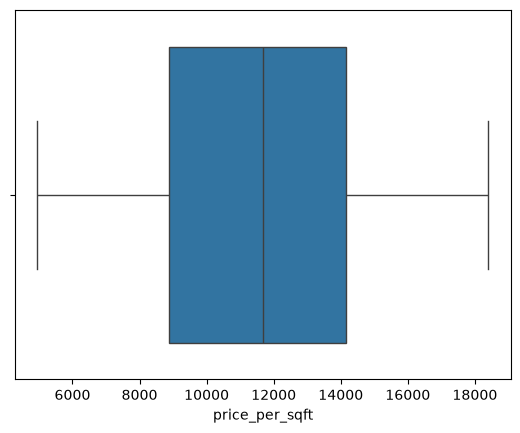

In [19]:
# Create column
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']

# Outlier handling
q1 = df['price_per_sqft'].quantile(0.25)
q3 = df['price_per_sqft'].quantile(0.75)

IQR = q3 - q1

lower = q1 - 0.5 * IQR
upper = q3 + 0.5 * IQR

df = df[(df['price_per_sqft'] > lower) & (df['price_per_sqft'] < upper)]

sns.boxplot(x='price_per_sqft', data=df)

In [20]:
df.reset_index(inplace=True)
df=df.drop(['index', 'size', "price_per_sqft"], axis=1)
df

,availability,location,total_sqft,bath,price,bhk
0,Ready To Move,Hennur Road,276.0,3,23.0,2
1,Ready To Move,Kumaraswami Layout,600.0,3,85.0,5
2,Ready To Move,other,1200.0,5,170.0,5
3,Ready To Move,Giri Nagar,880.0,3,140.0,3
4,Ready To Move,other,1200.0,5,180.0,5
...,...,...,...,...,...,...
341,Ready To Move,Nagavara,440.0,3,35.0,3
342,18-Apr,Yelahanka,1330.0,5,210.0,5
343,Ready To Move,other,250.0,2,40.0,1
344,Ready To Move,Margondanahalli,1375.0,5,125.0,5


In [21]:
from sklearn.preprocessing import LabelEncoder, StandardScaler,Normalizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [34]:
from sklearn.preprocessing import LabelEncoder

location_encoder = LabelEncoder()
availability_encoder = LabelEncoder()

df["encoded_location"] = location_encoder.fit_transform(df["location"])

df["encoded_availability"] = availability_encoder.fit_transform(
    df["availability"]
)

In [35]:
from sklearn.preprocessing import LabelEncoder

location_encoder = LabelEncoder()
availability_encoder = LabelEncoder()

df["encoded_location"] = location_encoder.fit_transform(df["location"])
df["encoded_availability"] = availability_encoder.fit_transform(df["availability"])

X = df[['encoded_availability',
        'total_sqft',
        'bath',
        'bhk',
        'encoded_location']]

y = df['price']

In [36]:
#split into train and test
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
print(X.columns.tolist())

['encoded_availability', 'total_sqft', 'bath', 'bhk', 'encoded_location']


In [38]:
print(X.shape)
print(X.columns.tolist())

(346, 5)
['encoded_availability', 'total_sqft', 'bath', 'bhk', 'encoded_location']


In [39]:
# Convert categorical columns into numeric columns
model = RandomForestRegressor(random_state=42)
params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20]
}
grid = GridSearchCV(
    estimator=model,
    param_grid=params,
    cv=5
)
grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)
print("Best score:", grid.best_score_)

Best parameters: {'max_depth': 10, 'n_estimators': 100}
Best score: 0.3457021680734135


In [40]:
ypred = grid.predict(X_test)

In [46]:
input_data = pd.DataFrame({
    "encoded_availability": [0],
    "total_sqft": [1000],
    "bath": [2],
    "bhk": [2],
    "encoded_location": [0]
})

In [42]:
print("Training Eff:", grid.score(X_train,y_train))
print("Testing Eff:", grid.score(X_test,y_test))

print("R2:", r2_score(y_test, ypred))
print("MAE:", mean_absolute_error(y_test, ypred))

# Save cleaned dataset
df.to_csv("cleaned_df.csv")

# Save model
import joblib
joblib.dump(grid,"rf_model.joblib")

Training Eff: 0.8346720813420665
Testing Eff: 0.3863209313375682
R2: 0.3863209313375682
MAE: 20.55463935945486


['rf_model.joblib']

In [43]:
sample = pd.DataFrame({
    "encoded_availability": [0],
    "total_sqft": [1000],
    "bath": [2],
    "bhk": [2],
    "encoded_location": [0]
})

prediction = grid.predict(sample)

print("Predicted Price:", prediction[0])

Predicted Price: 146.7352


In [48]:
import joblib

joblib.dump(grid.best_estimator_, "rf_model.joblib")
joblib.dump(location_encoder, "location_encoder.joblib")
joblib.dump(availability_encoder, "availability_encoder.joblib")

['availability_encoder.joblib']

In [49]:
sample = pd.DataFrame({
    "encoded_availability": [0],
    "total_sqft": [1000],
    "bath": [2],
    "bhk": [2],
    "encoded_location": [0]
})

prediction = grid.predict(sample)

print("Predicted Price:", prediction[0])

Predicted Price: 146.7352
